In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv('Real_estate_FeatureEng.csv')

In [3]:
df.sample(5)

,Unnamed: 0,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,...,address,floorNum,agePossession,furnishing_type,study room,servant room,store room,pooja room,others,luxury_score
2758,2758,1,99A,pareena coban residences,1.4,7010,1997,3,5,3,...,"Sector 99A Gurgaon, Gurgaon, Haryana",6.0,Relatively New,0,0,0,0,0,0,15
702,702,1,43,dlf carlton estate,2.0,14214,1407,3,3,2,...,"DLF Phase 5, Gurgaon, Haryana",5.0,Relatively Old,0,0,0,0,0,0,65
71,71,1,90,dlf regal gardens,1.7,7223,2354,4,4,3,...,"856, Sector 90 Gurgaon, Gurgaon, Haryana",15.0,Relatively Old,0,0,0,0,0,0,38
2235,2235,1,69,tulip violet,2.0,9583,2087,4,4,2,...,"002, Sector 69 Gurgaon, Gurgaon, Haryana",NaN,New,0,0,0,0,0,0,157
2790,2790,1,58,ireo the grand arch,3.8,17560,2164,3,4,1,...,"sector 58 Gurgaon, Gurgaon, Haryana",19.0,Relatively Old,2,0,0,0,0,0,167


### Missing value imputation fot floornum

In [4]:
df['floorNum'].value_counts()

floorNum
3.0     545
2.0     537
1.0     385
4.0     329
8.0     200
6.0     187
7.0     187
10.0    186
5.0     181
9.0     170
12.0    162
14.0    120
11.0    113
15.0     83
16.0     54
17.0     51
13.0     43
18.0     38
19.0     33
20.0     25
21.0     16
23.0     14
22.0     14
24.0     11
25.0      9
27.0      8
30.0      5
0.0       5
26.0      5
28.0      4
33.0      4
31.0      4
29.0      3
32.0      2
40.0      2
35.0      2
39.0      2
34.0      2
43.0      2
44.0      1
45.0      1
41.0      1
51.0      1
38.0      1
Name: count, dtype: int64

In [5]:
df[df['floorNum'].isnull()].sample(4)

,Unnamed: 0,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,...,address,floorNum,agePossession,furnishing_type,study room,servant room,store room,pooja room,others,luxury_score
250,250,1,104,zara aavaas,0.26,7807,333,1,1,2,...,"Ground Floor, Sector 104 Gurgaon, Gurgaon, Har...",NaN,New,0,0,0,0,0,0,91
5,5,1,113,la vida by tata housing,3.72,13984,2660,5,4,3,...,"B2 003, Sector 113 Gurgaon , Gurgaon, Haryana",NaN,Relatively New,1,0,0,0,0,0,44
319,319,1,79,supertech araville,0.78,6024,1295,2,2,3,...,"Sector 79 Gurgaon, Gurgaon, Haryana",NaN,Relatively New,0,0,0,0,0,0,74
242,242,0,86,dlf new town heights,2.47,7718,3200,4,4,3,...,"Sector 86 Gurgaon, Gurgaon, Haryana",NaN,Relatively Old,2,0,1,0,1,0,130


In [6]:
## Median floor num for Houses
df[df['F/H']==0]['floorNum'].median()

3.0

In [7]:
## Median floor num for Flats
df[df['F/H']==1]['floorNum'].median()

7.0

In [8]:
## Filling null values
flats_df=df[df['F/H']==1 & df['floorNum'].isnull()]
houses_df=df[df['F/H']==0 & df['floorNum'].isnull()]
df.loc[flats_df.index,'floorNum']=7.0
df.loc[houses_df.index,'floorNum']=3.0

In [9]:
df['agePossession'].value_counts()

agePossession
New                   1686
Relatively New         638
Relatively Old         599
undefined              354
Old                    345
Under Construction     281
Name: count, dtype: int64

In [10]:
def mode_based_imputation(row):
    if row['agePossession'] == 'undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['F/H'] == row['F/H'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']
    

In [11]:
df['agePossession']=df.apply(mode_based_imputation,axis=1)

In [12]:
df['agePossession'].value_counts()

agePossession
New                   1834
Relatively New         669
Relatively Old         643
Old                    385
Under Construction     298
undefined               74
Name: count, dtype: int64

In [13]:
def mode_based_imputation1(row):
    if row['agePossession'] == 'undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']
    

In [14]:
df['agePossession']=df.apply(mode_based_imputation1,axis=1)

In [15]:
df['agePossession'].value_counts()

agePossession
New                   1851
Relatively New         670
Relatively Old         661
Old                    393
Under Construction     298
undefined               30
Name: count, dtype: int64

In [16]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'undefined':
        mode_value = df[(df['F/H'] == row['F/H'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [17]:
df['agePossession']=df.apply(mode_based_imputation1,axis=1)

In [18]:
df['agePossession'].value_counts()

agePossession
New                   1851
Relatively New         670
Relatively Old         661
Old                    393
Under Construction     298
undefined               30
Name: count, dtype: int64

In [19]:
df[df['agePossession']=='undefined']

,Unnamed: 0,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,...,address,floorNum,agePossession,furnishing_type,study room,servant room,store room,pooja room,others,luxury_score
181,181,1,"7,",shyam apartment,0.66,5739,1150,3,3,2,...,"Near Ladyfatima School, New Colony, Sector 7, ...",2.0,undefined,0,0,0,0,0,0,0
486,486,0,105,indepedent,0.60,13333,450,3,3,0,...,"Rajendra Park, Sector 105, Rajendra Park, Gurg...",3.0,undefined,0,0,0,0,0,0,0
593,593,0,105,indepedent,1.10,12222,900,6,4,1,...,"Rajendra Park, Sector 105, Rajendra Park, Gurg...",3.0,undefined,0,0,0,0,0,0,0
672,672,0,105,indepedent,0.55,98214,56,4,4,0,...,"Rajendra Park, Sector 105, Rajendra Park, Gurg...",3.0,undefined,0,0,0,0,0,0,0
806,806,1,37A,ild greens,0.79,4476,1765,4,4,2,...,"Sector 37a, Delhi Gurgaon Expressway, Sector 3...",7.0,undefined,0,0,0,0,0,0,51
879,879,0,17,indepedent,0.32,22068,145,2,2,0,...,"Garhi Harsaru, Garhi Harsaru, Gurgaon, Haryana",3.0,undefined,0,0,0,0,0,0,0
1048,1048,0,Sector,indepedent,1.15,12777,900,2,2,3,...,"67028 Jyoti Park Gurgaon, New Jyoti Park, Gurg...",3.0,undefined,0,0,0,0,0,0,0
1089,1089,0,105,indepedent,0.38,76000,50,2,2,2,...,"Rajendra Park Block G, Sector 105, Rajendra Pa...",3.0,undefined,0,0,0,0,0,0,0
1163,1163,0,17,indepedent,3.50,218750,160,6,6,3,...,"Sector 17 Block B, Sector 17, Delhi Gurgaon Ex...",3.0,undefined,0,0,0,0,0,0,0
1200,1200,0,105,indepedent,9.90,49500,2000,2,2,2,...,"Mahalaxmi Garden Part-1, Rajendera Park, Secto...",3.0,undefined,0,0,0,0,0,0,0


In [20]:
temp_df=df[df['agePossession']=='undefined']
df.loc[temp_df.index,'agePossession']=np.nan

In [21]:
df=df.dropna(subset=['agePossession'])

In [22]:
df['agePossession'].value_counts()

agePossession
New                   1851
Relatively New         670
Relatively Old         661
Old                    393
Under Construction     298
Name: count, dtype: int64

In [23]:
df.isnull().sum()

Unnamed: 0          0
F/H                 0
sector              0
society             0
price               0
price_per_sqft      0
total_area(sqft)    0
bedRoom             0
bathroom            0
balcony             0
additionalRoom      0
address             0
floorNum            0
agePossession       0
furnishing_type     0
study room          0
servant room        0
store room          0
pooja room          0
others              0
luxury_score        0
dtype: int64

### OUTLIER DETECTION

C:\Users\HP\AppData\Local\Temp\ipykernel_3336\1625923990.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['price'])


<Axes: ylabel='Density'>

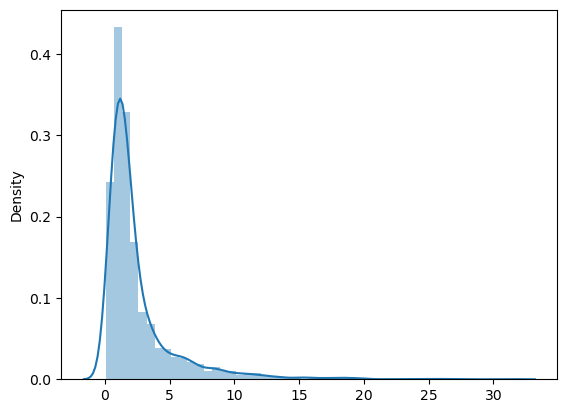

In [24]:
## Price
sns.distplot(x=df['price'])

<Axes: xlabel='price'>

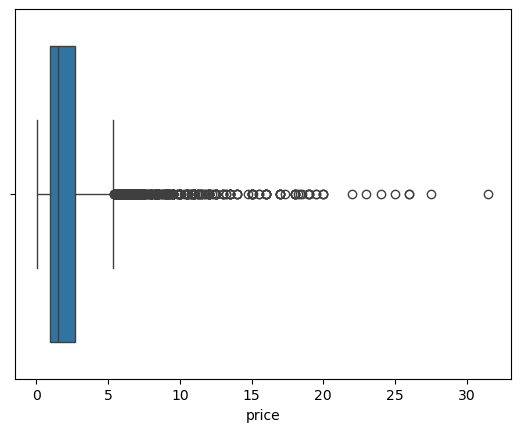

In [25]:
sns.boxplot(x=df['price'])

In [26]:
df['price'].describe()

count    3873.000000
mean        2.502401
std         2.948580
min         0.070000
25%         0.920000
50%         1.500000
75%         2.700000
max        31.500000
Name: price, dtype: float64

In [27]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(444,
 count    444.000000
 mean       9.169212
 std        4.059055
 min        5.400000
 25%        6.300000
 50%        8.000000
 75%       10.552500
 max       31.500000
 Name: price, dtype: float64)

<Axes: xlabel='price_per_sqft'>

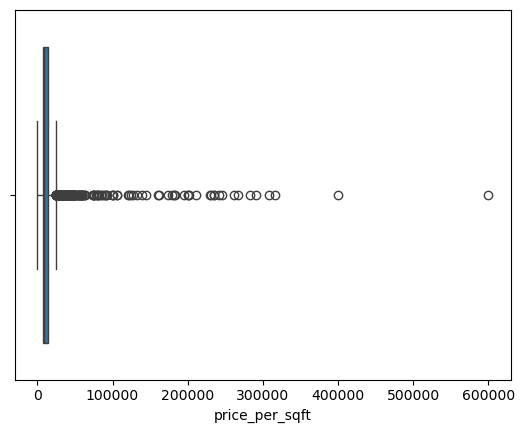

In [28]:
## Price_per_sqft
sns.boxplot(x=df['price_per_sqft'])

C:\Users\HP\AppData\Local\Temp\ipykernel_3336\279779110.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['price_per_sqft'])


<Axes: ylabel='Density'>

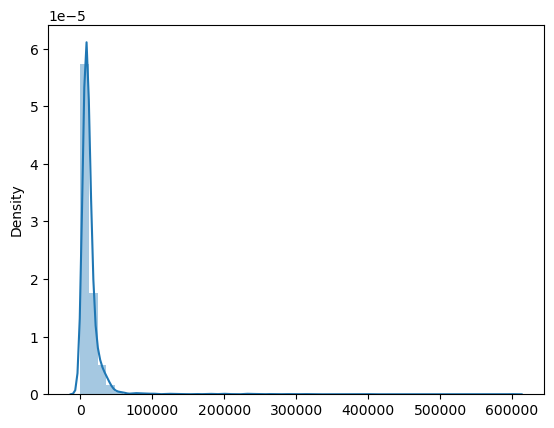

In [29]:
sns.distplot(x=df['price_per_sqft'])

In [30]:
df['price_per_sqft'].describe()

count      3873.000000
mean      13924.352440
std       23073.538031
min           2.000000
25%        6806.000000
50%        9000.000000
75%       13888.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

In [31]:
# Calculate the IQR for the 'price_per_sqft' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_per_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_price_per_sqft_stats

(444,
 count       369.000000
 mean      53534.875339
 std       60617.481904
 min       24545.000000
 25%       28283.000000
 50%       33951.000000
 75%       43066.000000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

### Got to know in above outlier dataset that area which is less then 1000 given in yards and we find price_per_sqft=price/area
### due to that area in sqft price per sqft value increses so we have to convert it to sqft
                1 yard = 9 sqft

In [32]:
outliers_sqft['total_area(sqft)']=outliers_sqft['total_area(sqft)'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\HP\AppData\Local\Temp\ipykernel_3336\2454440201.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['total_area(sqft)']=outliers_sqft['total_area(sqft)'].apply(lambda x:x*9 if x<1000 else x)


In [33]:
outliers_sqft['price_per_sqft']=round((outliers_sqft['price']*10000000)/outliers_sqft['total_area(sqft)'])

C:\Users\HP\AppData\Local\Temp\ipykernel_3336\2407470901.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft']=round((outliers_sqft['price']*10000000)/outliers_sqft['total_area(sqft)'])


In [34]:
outliers_sqft['price_per_sqft'].describe()

count      369.000000
mean     28932.623306
std      12549.942105
min       2727.000000
25%      25535.000000
50%      29697.000000
75%      35530.000000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [35]:
df.update(outliers_sqft)

<Axes: xlabel='price_per_sqft'>

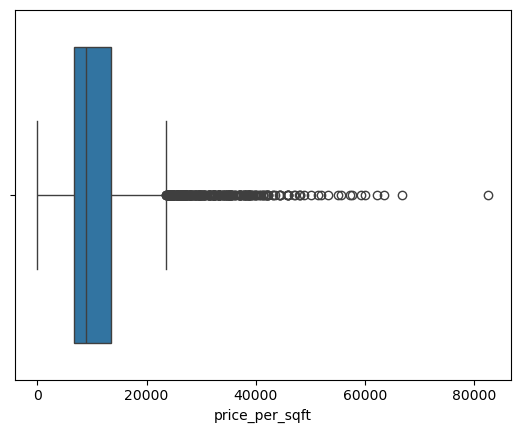

In [36]:
sns.boxplot(x=df['price_per_sqft'])

In [37]:
df[df['price_per_sqft']>50000]

,Unnamed: 0,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,...,address,floorNum,agePossession,furnishing_type,study room,servant room,store room,pooja room,others,luxury_score
789,789,0,66,emaar mgf marbella,18.00,55556,3240,4,4,3,...,"B10, Sector 66 Gurgaon, Gurgaon, Haryana",3.0,Relatively Old,1,1,1,0,1,0,75
1529,1529,0,26,indepedent,26.00,82540,3150,16,16,3,...,"Dlf Phase 1, DLF Phase 1, Gurgaon, Haryana",3.0,Relatively New,2,1,1,1,1,0,72
1818,1818,0,35,cloudnine cottages,5.50,55000,1000,3,3,0,...,"Sohna Road, Gurgaon, Haryana",3.0,Relatively Old,0,0,0,0,0,0,0
1896,1896,0,54,emaar the palm springs,24.00,66667,3600,5,5,2,...,"Sector 54 Gurgaon, Gurgaon, Haryana",3.0,Old,2,1,1,0,1,0,122
2152,2152,0,26,indepedent,14.75,51864,2844,16,20,3,...,"Luxurious Builder Floor, DLF Phase 1, Gurgaon,...",3.0,Relatively New,2,1,1,1,1,0,153
2294,2294,1,70,unitech vistas,9.00,57508,1565,3,3,0,...,"Sector 70, Sector 70 Gurgaon, Gurgaon, Haryana",7.0,New,0,0,0,0,0,0,0
2567,2567,0,26,dlf city plots,26.00,57206,4545,6,7,3,...,"0000, DLF Phase 1, Gurgaon, Haryana",3.0,Relatively New,2,1,1,0,1,1,138
2580,2580,0,54,emaar the palm springs,14.00,62222,2250,4,5,3,...,"The Palm Springs Villa, Sector 54 Gurgaon, Gur...",3.0,Old,2,1,1,0,0,0,160
3194,3194,0,47,malibu towne,8.50,53125,1600,12,12,3,...,"Redwood 14, Malibu Town, Gurgaon, Haryana",3.0,Relatively New,2,0,0,0,0,0,99
3634,3634,0,25,indepedent,16.00,59259,2700,16,16,3,...,"Dlf Phase 2, DLF Phase 2, Gurgaon, Haryana",3.0,Relatively New,2,1,1,1,1,0,72


In [38]:
df=df[df['price_per_sqft']<=50000]

<Axes: xlabel='price_per_sqft'>

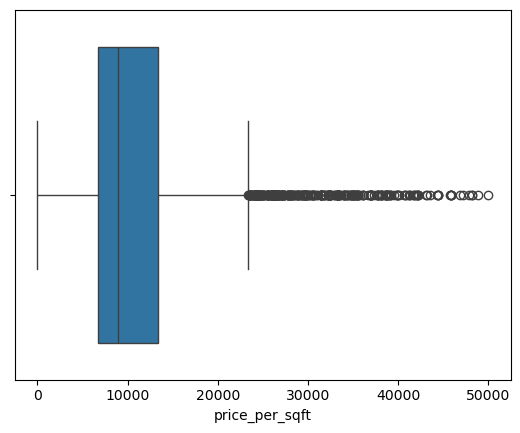

In [39]:
sns.boxplot(x=df['price_per_sqft'])

## Area 

In [40]:
pd.options.display.float_format='{:.2f}'.format
df['total_area(sqft)'].describe()

count      3860.00
mean       4772.33
std      118811.20
min         225.00
25%        1250.00
50%        1741.50
75%        2340.25
max     7250000.00
Name: total_area(sqft), dtype: float64

In [41]:
df[df['total_area(sqft)']>100000]  ## these are not valid outliers not possible

,Unnamed: 0,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,...,address,floorNum,agePossession,furnishing_type,study room,servant room,store room,pooja room,others,luxury_score
401,401,0,37,indepedent,1.45,2,7250000,4,3,3,...,"Pataudi Road, Gurgaon, Haryana",3.00,Relatively Old,0,0,0,0,0,0,0
966,966,0,50,indepedent,5.00,232,215517,6,5,3,...,"Sector 50 Gurgaon, Gurgaon, Haryana",3.00,Relatively New,2,1,1,0,1,1,0
1700,1700,1,95A,signature the roselia,0.45,7,642857,2,2,2,...,"Sector 95A Gurgaon, Gurgaon, Haryana",2.00,Relatively New,0,0,0,0,0,0,76
2796,2796,1,107,signature global solera 2,0.51,9,566667,2,2,1,...,"A5 301, Sector 107 Gurgaon, Gurgaon, Haryana",3.00,Relatively New,0,0,0,0,0,0,44
2993,2993,1,35,hcbs sports ville,0.35,4,875000,2,2,2,...,"Sohna, Gurgaon, Haryana",8.00,New,1,0,0,0,0,0,44
3083,3083,1,95,ramsons kshitij,0.31,5,620000,2,2,1,...,"Sector 95 Gurgaon, Gurgaon, Haryana",1.00,New,0,0,0,0,0,0,65


In [42]:
df=df[df['total_area(sqft)']<100000]

In [43]:
df['total_area(sqft)'].describe()

count    3854.00
mean     2140.93
std      3635.83
min       225.00
25%      1246.25
50%      1741.00
75%      2339.50
max     98978.00
Name: total_area(sqft), dtype: float64

<Axes: xlabel='total_area(sqft)'>

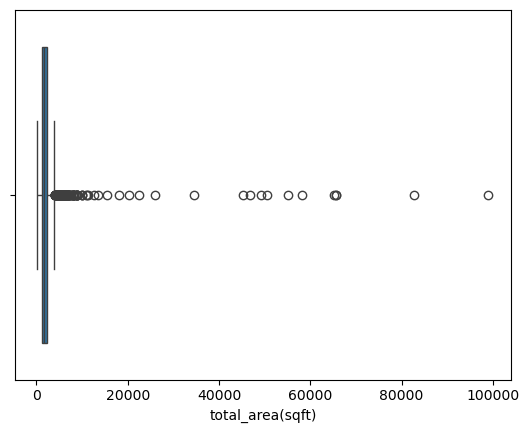

In [44]:
sns.boxplot(x=df['total_area(sqft)'])

In [45]:
df[df['total_area(sqft)']>10000]

,Unnamed: 0,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,...,address,floorNum,agePossession,furnishing_type,study room,servant room,store room,pooja room,others,luxury_score
116,116,1,95,rof anot availableda,0.38,58,65517,2,2,2,...,"E1002, Sector 95 Gurgaon, Gurgaon, Haryana",10.00,Relatively New,0,0,0,0,0,0,15
184,184,0,26,indepedent,18.40,1859,98978,6,8,3,...,"111, DLF Phase 1, Gurgaon, Haryana",3.00,New,2,0,1,1,1,0,60
294,294,0,51,indepedent,5.50,1087,50598,8,8,2,...,"12356, Mayfield Garden, Gurgaon, Haryana",3.00,New,2,0,0,0,1,0,49
346,346,0,13,ganpati heights apartment,1.25,151,82781,10,6,2,...,"Prem Nagar, Gurgaon, Haryana",3.00,Old,0,0,0,0,0,1,7
442,442,0,50,unitech aspen greens,6.95,4490,15479,3,3,1,...,"Lm 96, Nirvana Country, Gurgaon, Haryana",3.00,Relatively Old,0,0,1,0,0,0,160
526,526,0,43,indepedent,27.50,24366,11286,6,7,3,...,"Sushant Lok 1, Sushant Lok Phase 1, Gurgaon, H...",3.00,New,2,1,1,0,1,1,42
714,714,1,35,signature the serenas,0.28,57,49123,1,1,2,...,"0001, Sohna, Gurgaon, Haryana",1.00,New,0,0,0,0,0,0,37
810,810,0,28,dlf city plot phase 4,13.00,1992,65261,10,10,3,...,"Dlf City Phase 4, Sector 28, DLF Phase 4, Gurg...",3.00,New,0,0,0,0,0,0,0
1056,1056,1,95,rof anot availableda,0.38,58,65517,3,2,1,...,"Sector 95 Gurgaon, Gurgaon, Haryana",12.00,New,0,0,0,0,0,0,51
1575,1575,1,65,m3m golfestate,13.20,12000,11000,4,4,3,...,"Sector 65 Gurgaon, Gurgaon, Haryana",13.00,Relatively Old,0,0,0,0,0,0,60


In [46]:
## 116,184,714,1056,2043,3156,3215,3446,3296,3510,

In [47]:
df.drop(index=[116,184,714,1056,2043,3156,3215,3446,3296,3510], inplace=True)

In [48]:

df[df['total_area(sqft)'] > 10000].sort_values('total_area(sqft)',ascending=False)

,Unnamed: 0,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,...,address,floorNum,agePossession,furnishing_type,study room,servant room,store room,pooja room,others,luxury_score
346,346,0,13,ganpati heights apartment,1.25,151,82781,10,6,2,...,"Prem Nagar, Gurgaon, Haryana",3.00,Old,0,0,0,0,0,1,7
810,810,0,28,dlf city plot phase 4,13.00,1992,65261,10,10,3,...,"Dlf City Phase 4, Sector 28, DLF Phase 4, Gurg...",3.00,New,0,0,0,0,0,0,0
3293,3293,1,86,pyramid elite,0.46,79,58228,2,2,1,...,"Sector 86 Gurgaon, Gurgaon, Haryana",7.00,Under Construction,0,0,0,0,0,0,15
294,294,0,51,indepedent,5.50,1087,50598,8,8,2,...,"12356, Mayfield Garden, Gurgaon, Haryana",3.00,New,2,0,0,0,1,0,49
3234,3234,0,25,indepedent,7.30,1560,46795,9,9,2,...,"Dlf Phase 2, DLF Phase 2, Gurgaon, Haryana",3.00,New,2,0,1,1,0,0,109
3458,3458,0,57,indepedent,6.25,2778,22498,9,9,3,...,"26.........., Sector 57 Gurgaon, Gurgaon, Haryana",3.00,Relatively New,2,0,1,0,0,0,61
3266,3266,0,43,indepedent,5.50,2716,20250,8,7,3,...,"Sushant Lok Phase 1, Gurgaon, Haryana",3.00,Relatively Old,2,1,1,0,1,1,123
3569,3569,1,85,godrej air,2.50,1379,18129,4,5,3,...,"1601-A 2, Sector 85 Gurgaon, Gurgaon, Haryana",16.00,Under Construction,2,0,0,0,0,0,44
442,442,0,50,unitech aspen greens,6.95,4490,15479,3,3,1,...,"Lm 96, Nirvana Country, Gurgaon, Haryana",3.00,Relatively Old,0,0,1,0,0,0,160
2011,2011,1,88A,godrej icon,1.75,1384,12645,3,3,3,...,"Sector 88A Gurgaon, Gurgaon, Haryana",6.00,Relatively New,0,0,0,0,0,0,55


In [49]:
df['total_area(sqft)'].describe()

count    3844.00
mean     2028.15
std      2543.90
min       225.00
25%      1245.00
50%      1740.00
75%      2325.00
max     82781.00
Name: total_area(sqft), dtype: float64

<Axes: xlabel='total_area(sqft)'>

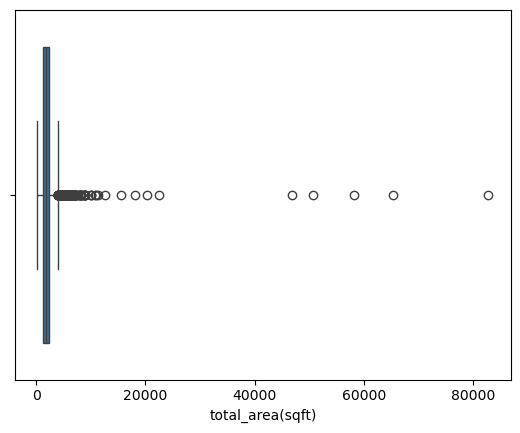

In [50]:
sns.boxplot(x=df['total_area(sqft)'])

## Bedroom

In [51]:
df['bedRoom'].describe()

count   3844.00
mean       3.34
std        1.96
min        1.00
25%        2.00
50%        3.00
75%        4.00
max       36.00
Name: bedRoom, dtype: float64

<Axes: xlabel='bedRoom'>

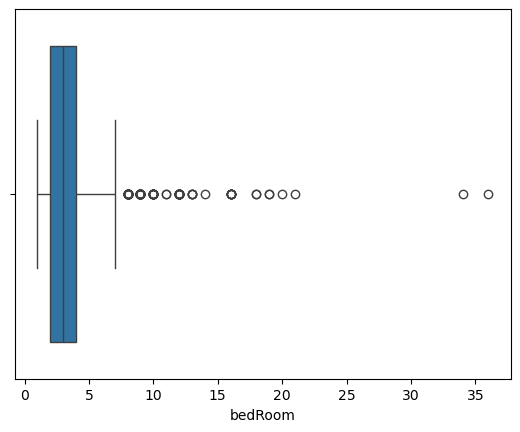

In [52]:
sns.boxplot(x=df['bedRoom'])

In [53]:
df[df['bedRoom']>10]

,Unnamed: 0,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,...,address,floorNum,agePossession,furnishing_type,study room,servant room,store room,pooja room,others,luxury_score
49,49,0,43,indepedent,13.50,50000,2700,16,16,3,...,"C Block, Sushant Lok Phase 1, Gurgaon, Haryana",3.00,New,0,1,1,0,1,1,41
50,50,0,43,indepedent,4.50,39062,1152,20,20,3,...,"Sushant Lok Phase 1, Gurgaon, Haryana",3.00,New,1,0,1,0,0,0,22
235,235,0,17A,indepedent,3.87,5160,7500,19,17,3,...,"690, Sector 17A Gurgaon, Gurgaon, Haryana",3.00,New,0,1,0,1,0,0,68
273,273,0,13,indepedent,0.50,10101,495,12,4,3,...,"Rajiv Nagar, Gurgaon, Haryana",3.00,Old,0,0,0,0,0,0,15
318,318,0,14,indepedent,8.00,17707,4518,12,4,3,...,"Mehrauli Gurgaon Road, Gurgaon, Haryana",3.00,Old,0,0,1,1,0,0,32
440,440,0,26,dlf city phase 1,9.25,47804,1935,12,12,3,...,"A Block Excellent Location, Sector 26 Gurgaon,...",3.00,Relatively New,2,0,1,0,1,0,43
515,515,0,57,indepedent,9.19,34037,2700,16,18,2,...,"342, Sushant Lok Phase 2, Gurgaon, Haryana",3.00,Relatively New,2,0,1,0,1,0,49
590,590,0,25,floor wise designer kothi,13.00,48148,2700,12,16,3,...,"Floor Wise Designer Kothi, DLF Phase 2, Gurgao...",3.00,Relatively New,2,1,1,1,1,0,144
646,646,0,27,indepedent,8.25,45833,1800,12,12,3,...,"Sector 28 Gurgaon, Sector 27 Gurgaon, Gurgaon,...",3.00,Relatively New,2,0,1,0,1,0,40
687,687,0,31,indepedent,9.25,39530,2340,12,12,3,...,"Near Huda Market, Sector 31 Gurgaon, Gurgaon, ...",3.00,Relatively New,1,0,1,0,1,1,49


In [54]:
df=df[df['bedRoom']<10]

<Axes: xlabel='bedRoom'>

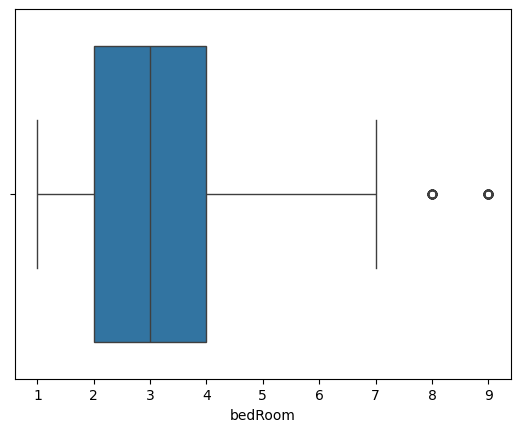

In [55]:
sns.boxplot(x=df['bedRoom'])

C:\Users\HP\AppData\Local\Temp\ipykernel_3336\3997226259.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['bedRoom'])


<Axes: ylabel='Density'>

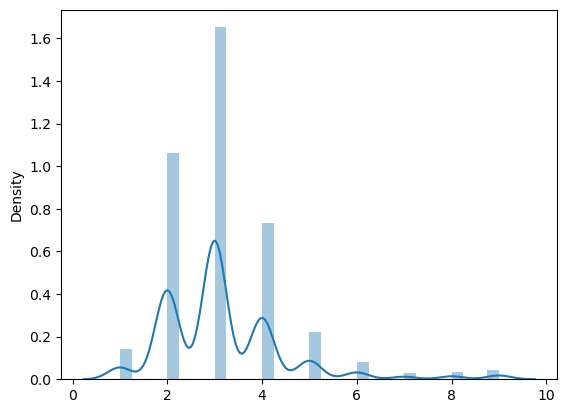

In [56]:
sns.distplot(x=df['bedRoom'])

## BATHROOM

In [57]:
df['bathroom'].describe()

count   3774.00
mean       3.23
std        1.41
min        1.00
25%        2.00
50%        3.00
75%        4.00
max       12.00
Name: bathroom, dtype: float64

<Axes: xlabel='bathroom'>

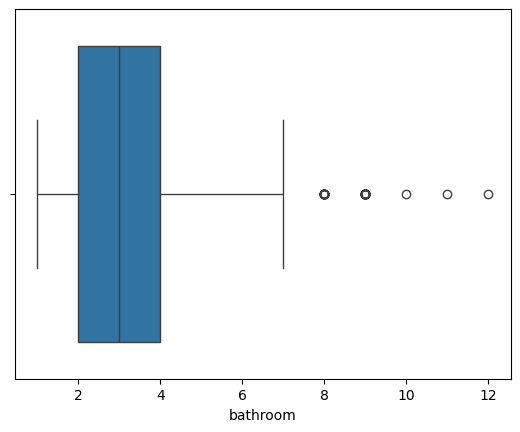

In [58]:
sns.boxplot(x=df['bathroom'])

In [59]:
df[df['bathroom']>10] ## these are valid outliers

,Unnamed: 0,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,...,address,floorNum,agePossession,furnishing_type,study room,servant room,store room,pooja room,others,luxury_score
1264,1264,0,24,indepedent,11.00,28902,3806,8,11,3,...,"Dlf -3, DLF Phase 3, Gurgaon, Haryana",3.00,Old,2,1,1,0,1,1,39
2615,2615,0,60,adani brahma samsara,18.02,28200,6390,9,12,3,...,"Sector 60 Gurgaon, Gurgaon, Haryana",3.00,New,2,0,1,0,0,0,146


## Balcony

In [60]:
df['balcony'].describe() ## no outliers

count   3774.00
mean       2.39
std        0.86
min        0.00
25%        2.00
50%        3.00
75%        3.00
max        3.00
Name: balcony, dtype: float64

## Floor Num

In [61]:
df['floorNum'].describe() ### no outliers

count   3774.00
mean       7.10
std        5.70
min        1.00
25%        3.00
50%        5.00
75%       10.00
max       45.00
Name: floorNum, dtype: float64

### Luxury score

In [62]:
df['luxury_score'].describe()

count   3774.00
mean      70.49
std       53.00
min        0.00
25%       30.00
50%       58.00
75%      109.00
max      174.00
Name: luxury_score, dtype: float64

<Axes: ylabel='luxury_score'>

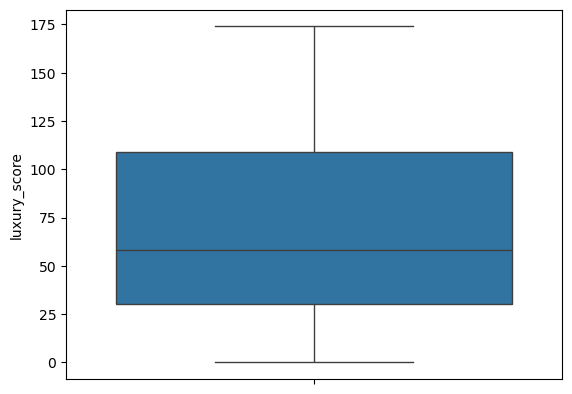

In [63]:
sns.boxplot(df['luxury_score'])

In [66]:
df.to_csv('Real_estate_MissingValues_OutlierDetection.csv')